In [3]:
import pandas as pd
import numpy as np
rng = np.random.default_rng()
import matplotlib.pyplot as plt
import matplotlib as mpl
from skimage.measure import block_reduce

#### Functions

In [89]:
def multivariate_lognormal_cascade(n, sigma1=1, sigma2=1, rho=0):
    mu1 = -1/2 * sigma1**2
    mu2 = -1/2 * sigma2**2

    PQ = np.exp(rng.multivariate_normal(np.array([mu1,mu2]),  np.array([[sigma1**2,corr*sigma1*sigma2], [corr*sigma1*sigma2, sigma2**2]]), 4))

    P = PQ[:,0].reshape(2,2)
    Q = PQ[:,1].reshape(2,2)
    for i in range(n):
        PQ = np.exp(rng.multivariate_normal(np.array([mu1,mu2]),np.array([[sigma1**2,rho*sigma1*sigma2], [rho*sigma1*sigma2, sigma2**2]]), P.shape[0]**2 * 4))
        P = np.kron(P, np.ones((2,2)))
        P = P * PQ[:,0].reshape(P.shape)
        Q = np.kron(Q, np.ones((2,2)))
        Q = Q * PQ[:,1].reshape(P.shape)

    P = P / np.sum(P)
    Q = Q / np.sum(Q)
    return(np.stack([P,Q], axis=-1))

def multiscale_estimation(pop):  
    c1_1s, c2_1s, c1_2s, c2_2s, rhos = [], [], [], [], []
    sizes = 2**np.arange(np.log2(pop.shape[0])).astype(np.int32)
    for i in sizes:
        pop_reduce = block_reduce(pop, block_size = (i,i,1), func = np.sum)

        pop_reduce1 = pop_reduce[:,:,0][pop_reduce[:,:,0]>0].flatten()
        c1_1s.append(np.mean(np.log(pop_reduce1), ))
        c2_1s.append(np.var(np.log(pop_reduce1)))
        pop_reduce2 = pop_reduce[:,:,1][pop_reduce[:,:,1]>0].flatten()
        c1_2s.append(np.mean(np.log(pop_reduce2)))
        c2_2s.append(np.var(np.log(pop_reduce2)))

        pop_reduce1 = pop_reduce[:,:,0][(pop_reduce[:,:,0]>0) & (pop_reduce[:,:,1]>0)].flatten()
        pop_reduce2 = pop_reduce[:,:,1][(pop_reduce[:,:,0]>0) & (pop_reduce[:,:,1]>0)].flatten()        
        rhos.append(np.corrcoef(np.log(pop_reduce1).flatten(), np.log(pop_reduce2).flatten())[1,0])
        
    return(pd.DataFrame({'sizes': sizes, 'log_sizes' : np.log2(sizes), 'c1_1s' : c1_1s, 'c2_1s': c2_1s, 'c1_2s' : c1_2s, 'c2_2s': c2_2s, 'rhos': rhos}))

def multifractale_estimation(df):
    coefreg = (df.log_sizes - df.log_sizes.mean()) / np.sum((df.log_sizes - df.log_sizes.mean())**2)
    c1_1 = np.sum((df.c1_1s - np.mean(df.c1_1s)) * coefreg)
    c2_1 = -np.sum((df.c2_1s - np.mean(df.c2_1s)) * coefreg)
    c1_2 = np.sum((df.c1_2s - np.mean(df.c1_2s)) * coefreg)
    c2_2 = -np.sum((df.c2_2s - np.mean(df.c2_2s)) * coefreg)
    rho = df.rhos.mean()
    return({'c1_1':c1_1, 'c2_1' : c2_1, 'c1_2':c1_2, 'c2_2':c2_2, 'rho':rho  }) 
    

#### Analyzes

In [90]:
sizes = 2**np.arange(8) 
sigma1, sigma2, corr = 0.2, 0.4, 0.7

In [91]:
lnc = multivariate_lognormal_cascade(6, sigma1=sigma1, sigma2=sigma2, rho=corr)
scale_index = multiscale_estimation(lnc)
scale_index

,sizes,log_sizes,c1_1s,c2_1s,c1_2s,c2_2s,rhos
0,1,0.0,-9.842540,0.282416,-10.131950,0.859691,0.647744
1,2,1.0,-8.441416,0.252675,-8.687267,0.742550,0.641598
2,4,2.0,-7.036287,0.216215,-7.227182,0.601094,0.632045
3,8,3.0,-5.630230,0.176322,-5.763357,0.444182,0.614294
4,16,4.0,-4.226460,0.140563,-4.306676,0.302175,0.625512
5,32,5.0,-2.823086,0.104162,-2.865807,0.182525,0.558741
6,64,6.0,-1.430918,0.092236,-1.452893,0.138021,0.651666


<Axes: xlabel='log_sizes', ylabel='c1_1s'>

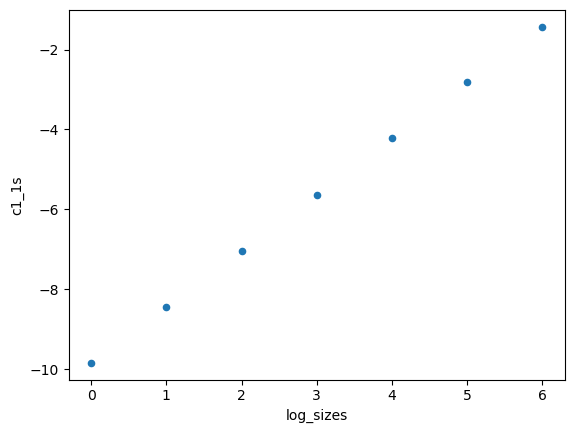

In [92]:
scale_index.plot.scatter('log_sizes', 'c1_1s')

In [93]:
df = scale_index.iloc[1:5]

In [94]:
feature = multifractale_estimation(df)
feature

{'c1_1': 1.405092503183625,
 'c2_1': 0.03762288297633109,
 'c1_2': 1.4605601186645638,
 'c2_2': 0.14780389760544926,
 'rho': 0.6283621182302651}

In [101]:
print(feature['c2_1']**.5, ((feature['c1_1'] - 2*np.log(2))*2)**.5)
print(feature['c2_2']**.5, ((feature['c1_2'] - 2*np.log(2))*2)**.5)

0.19396619029184206 0.19389761248522078
0.38445272479909576 0.3853978659636642


In [96]:
2*np.log(2) + sigma1**2/2

1.4062943611198906

In [152]:
paris = np.load('paris_household.npy')
print(paris.sum(axis=(0,1)))
paris = paris[32:96, 32:96,:]
#paris[paris==0] = 1
paris[:,:,0] = paris[:,:,0] / paris[:,:,0].sum() 
paris[:,:,1] = paris[:,:,1] / paris[:,:,1].sum() 

[ 415654.4 2329657.1]


In [137]:
paris.shape

(64, 64, 2)

C:\Users\francois.semecurbe\AppData\Local\Temp\ipykernel_17872\1739913897.py:1: RuntimeWarning: invalid value encountered in divide
  plt.imshow(paris[:,:,0]/(paris[:,:,0]+paris[:,:,1]) )


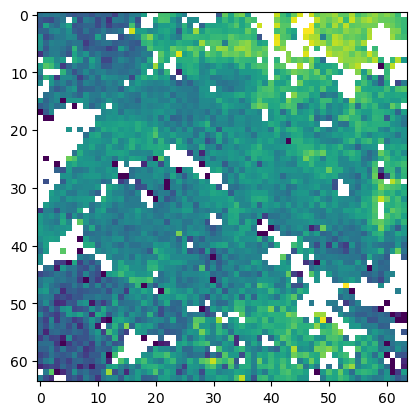

In [165]:
plt.imshow(paris[:,:,0]/(paris[:,:,0]+paris[:,:,1]) )

In [139]:
scale_index = multiscale_estimation(paris)
scale_index

,sizes,log_sizes,c1_1s,c2_1s,c1_2s,c2_2s,rhos
0,1,0.0,-8.724948,1.894181,-8.697052,1.921963,0.885831
1,2,1.0,-7.376976,1.773759,-7.386292,1.980529,0.904983
2,4,2.0,-5.918379,1.506025,-5.886009,1.276549,0.915639
3,8,3.0,-4.357907,0.483292,-4.335466,0.417890,0.809462
4,16,4.0,-2.881556,0.235946,-2.849047,0.159959,0.744384
5,32,5.0,-1.428543,0.078515,-1.390399,0.008027,0.885339


<Axes: xlabel='log_sizes', ylabel='c1_2s'>

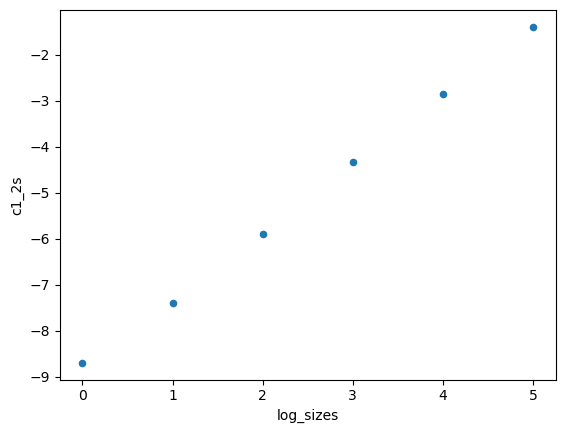

In [164]:
scale_index.plot.scatter('log_sizes', 'c1_2s')

,sizes,log_sizes,c1_1s,c2_1s,c1_2s,c2_2s,rhos
4,16,4.0,-4.536185,0.913454,-4.464685,0.648876,0.832144
5,32,5.0,-3.016669,0.500457,-2.986313,0.407596,0.816332
6,64,6.0,-1.440243,0.105662,-1.386724,0.000868,0.755216


In [162]:
df = scale_index.iloc[3:5]
print(df)
paris_feature = multifractale_estimation(df)

   sizes  log_sizes     c1_1s     c2_1s     c1_2s     c2_2s      rhos
3      8        3.0 -4.357907  0.483292 -4.335466  0.417890  0.809462
4     16        4.0 -2.881556  0.235946 -2.849047  0.159959  0.744384


In [163]:
print(paris_feature['c2_1']**.5, ((paris_feature['c1_1'] - 2*np.log(2))*2)**.5)
print(paris_feature['c2_2']**.5, ((paris_feature['c1_2'] - 2*np.log(2))*2)**.5)

0.49733862300674236 0.42439840337162293
0.5078690086265857 0.44749271671627694


In [132]:
paris_feature['c2_2']**.5

0.6377520025907668

In [ ]:
2*np.log(2) + sigma1**2/2